In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [8]:
def load_and_clean_data(file_path: str):
    df = pd.read_csv('amazon_reviews.csv')
    df = df.dropna(subset=['Review Text'])
    df['Target'] = df['Rating'].apply(lambda x: 1 if x > 3 else 0)
    df_clean = df.copy()
    drop_cols = ['User Verified', 'Review Useful Count', 'Declaration Text']
    df_clean = df_clean.drop(columns=drop_cols, axis=1)
    print(f"Data loaded successfully. Shape: {df_clean.shape}")
    return df_clean

DATA_FILE = 'amazon_reviews.csv'
processed_df = load_and_clean_data(DATA_FILE)
processed_df.head()
    

Data loaded successfully. Shape: (6850, 8)


,Pageurl,Title,Review Text,Review Color,Review Date,Configuration Text,Rating,Target
0,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Three Stars,Not great speakers,Black,10/3/2017,Echo Dot,3,0
1,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Four Stars,Great little gagit,White,9/26/2017,Echo Dot,4,1
2,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Awesome!,Awesome 👏🏽,White,9/8/2017,Echo Dot,5,1
3,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Love my Echo,Black,10/19/2017,Echo Dot,5,1
4,https://www.amazon.com/All-New-Amazon-Echo-Dot...,Five Stars,Great device,Black,9/17/2017,Echo Dot,5,1


In [15]:
def prepare_features(df: pd.DataFrame) -> Tuple[csr_matrix, pd.Series, TfidfVectorizer]:
    print("Vectorizing text data...")
    tfidf = TfidfVectorizer(stop_words='english', max_features=3000, ngram_range=(1, 2))
    
    X = tfidf.fit_transform(df['Review Text'])
    y = df['Target']
    
    return X, y, tfidf

X, y, tfidf = prepare_features(processed_df)
print(f"X shape (Sparse Matrix): {X.shape}")

Vectorizing text data...
X shape (Sparse Matrix): (6850, 3000)


In [18]:
def plot_project_visualizations(results_df: pd.DataFrame):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))
    
    df_melted = pd.melt(results_df, id_vars="Model", var_name="Metric", value_name="Value")
    sns.barplot(x="Model", y="Value", hue="Metric", data=df_melted, palette="muted")
    
    plt.title("Model Benchmarking & Performance Comparison", fontsize=14, fontweight='bold', pad=15)
    plt.ylim(0.7, 1.0)
    plt.ylabel("Score")
    plt.xlabel("Machine Learning Algorithms")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

Splitting dataset into Train and Test sets (80/20)...
Training Multinomial Naive Bayes model...

Overall Accuracy: 89.42%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       300
           1       0.92      0.95      0.93      1070

    accuracy                           0.89      1370
   macro avg       0.86      0.82      0.84      1370
weighted avg       0.89      0.89      0.89      1370




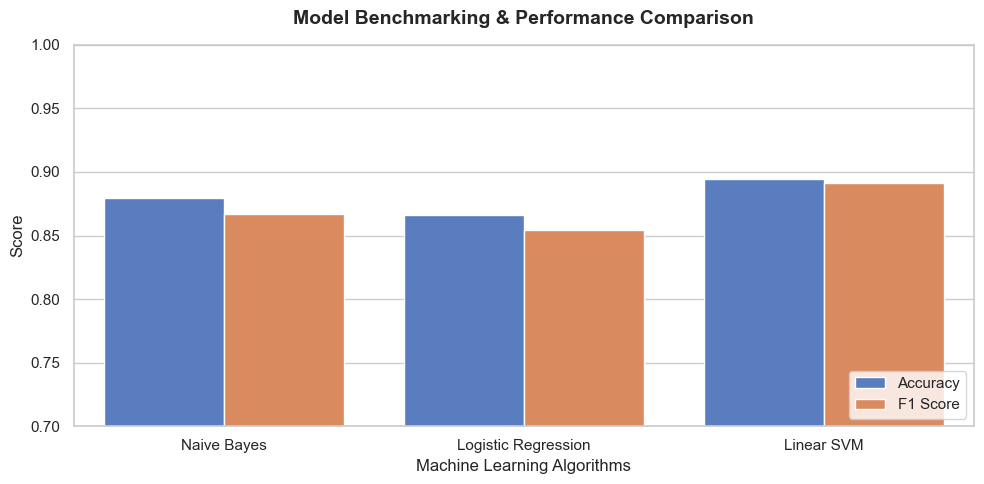

In [21]:
def train_and_evaluate_model(df: pd.DataFrame) -> pd.DataFrame:
    print("Splitting dataset into Train and Test sets (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("Training Multinomial Naive Bayes model...")
    models = {
        "Naive Bayes": MultinomialNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
        "Linear SVM": LinearSVC(random_state=42)
    }
    results = []
    trained_models = {}
    for model_name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results.append({'Model': model_name, 'Accuracy': accuracy, 'F1 Score': f1})
        trained_models[model_name] = model
    
    print("\n" + "="*40)
    print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("="*40 + "\n")
    
  
    return pd.DataFrame(results), tfidf, trained_models["Linear SVM"]

metrics_df, tfidf, final_model = train_and_evaluate_model(processed_df)

plot_project_visualizations(metrics_df)


In [22]:
import joblib


joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(final_model, 'sentiment_model.pkl')
print("Models saved successfully!")

Models saved successfully!


In [ ]:
processed_df.to_csv('cleaned_amazon_reviews.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def scrape_amazon_reviews(product_url: str):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept-Language": "en-US,en;q=0.9"
    }
    

    if "/dp/" in product_url:
        product_url = product_url.replace("/dp/", "/product-reviews/")
        
    print(f"[INFO] Fetching reviews from: {product_url}")
    response = requests.get(product_url, headers=headers)
    
    if response.status_code != 200:
        print(f"[ERROR] Failed to fetch page. Status code: {response.status_code}")
        return []
        
    soup = BeautifulSoup(response.content, "html.parser")
    

    review_elements = soup.find_all("span", {"data-hook": "review-body"})
    
    reviews = []
    for el in review_elements:
        review_text = el.get_text().strip()
        if review_text:
            reviews.append(review_text)
            
    print(f"[SUCCESS] Found {len(reviews)} live reviews!")
    return reviews

test_url = "https://www.amazon.com/dp/B07FZ8S74R" 
live_reviews = scrape_amazon_reviews(test_url)

print("\nSample Review:")
if live_reviews:
    print(live_reviews[0])
else:
    print("No reviews found. Amazon might be blocking the request, we will handle it!")

[INFO] Fetching reviews from: https://www.amazon.com/product-reviews/B07FZ8S74R
[SUCCESS] Found 0 live reviews!

Sample Review:
No reviews found. Amazon might be blocking the request, we will handle it!
